In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Generate dataset
np.random.seed(42)  # For reproducibility

# Train dataset: Uniform distribution between 0 and 1
x_train = np.random.uniform(0, 1, (1000, 2))
y_train = np.where(x_train[:, 1] > 1 - x_train[:, 0], 1, 0)  # Classify based on y > 1 - x

# Test dataset: Uniform distribution between 0 and 1
x_test = np.random.uniform(0, 1, (1000, 2))
y_test = np.where(x_test[:, 1] > 1 - x_test[:, 0], 1, 0)  # True labels for testing


# Create a DataFrame for easier manipulation and visualization
feature_columns = [f"feature_{i+1}" for i in range(x_train.shape[1])]
df = pd.DataFrame(x_train, columns=feature_columns)
df['label'] = y_train

test_df = pd.DataFrame(x_test, columns=feature_columns)
test_df['label'] = y_test



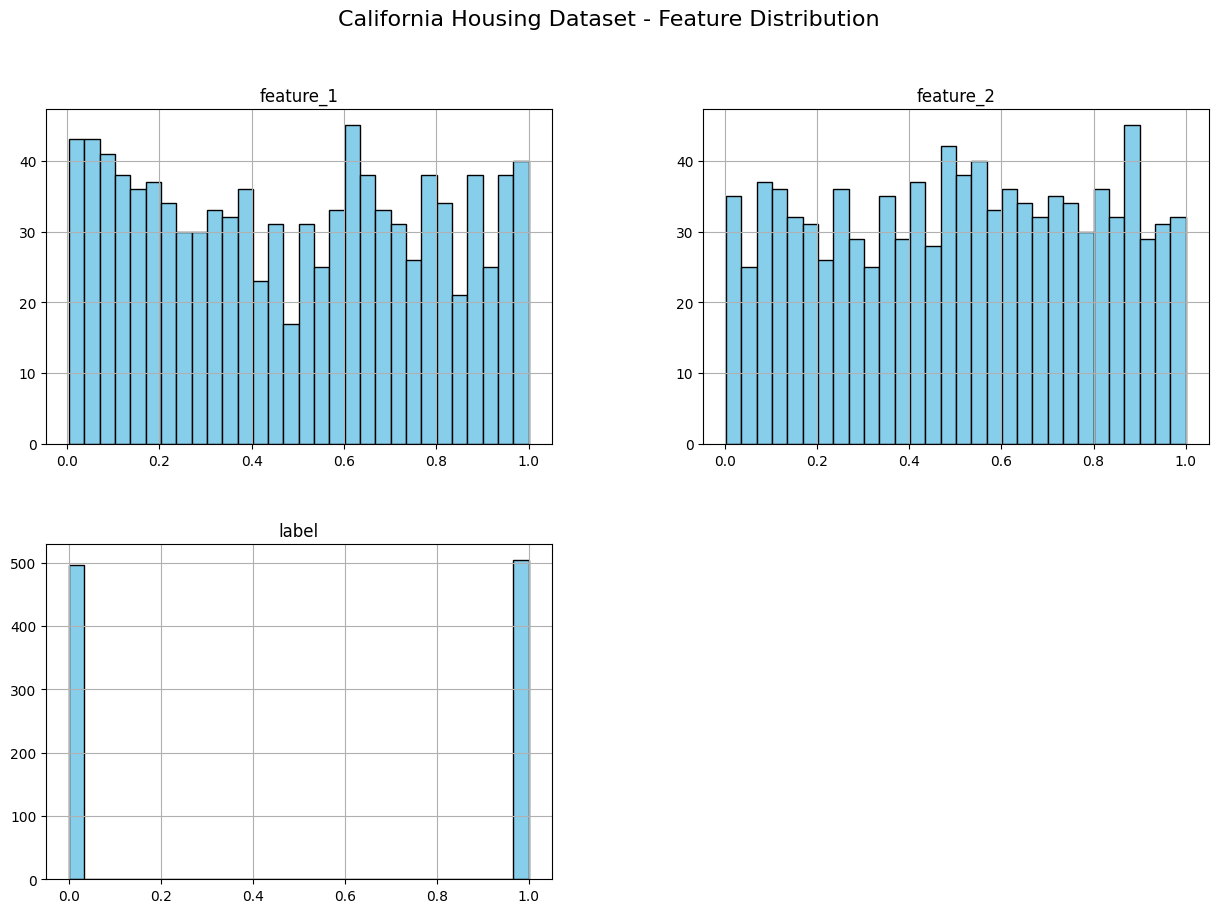

In [3]:
df.hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("California Housing Dataset - Feature Distribution", fontsize=16)
plt.show()

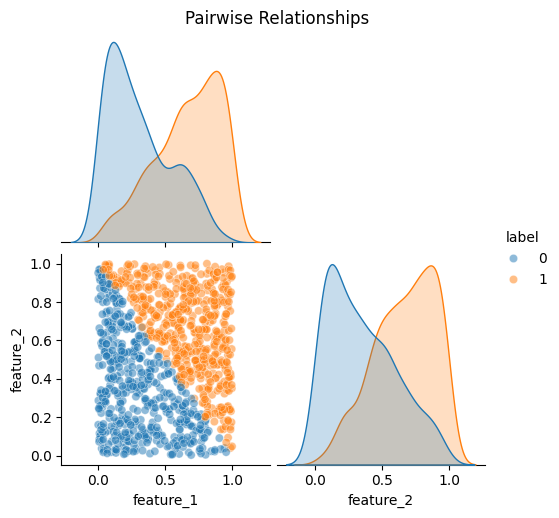

In [4]:
sns.pairplot(df, corner=True, hue='label', diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

### y = 1-x
### class 1 if y > 1-x
### o.w 0

# Part 1

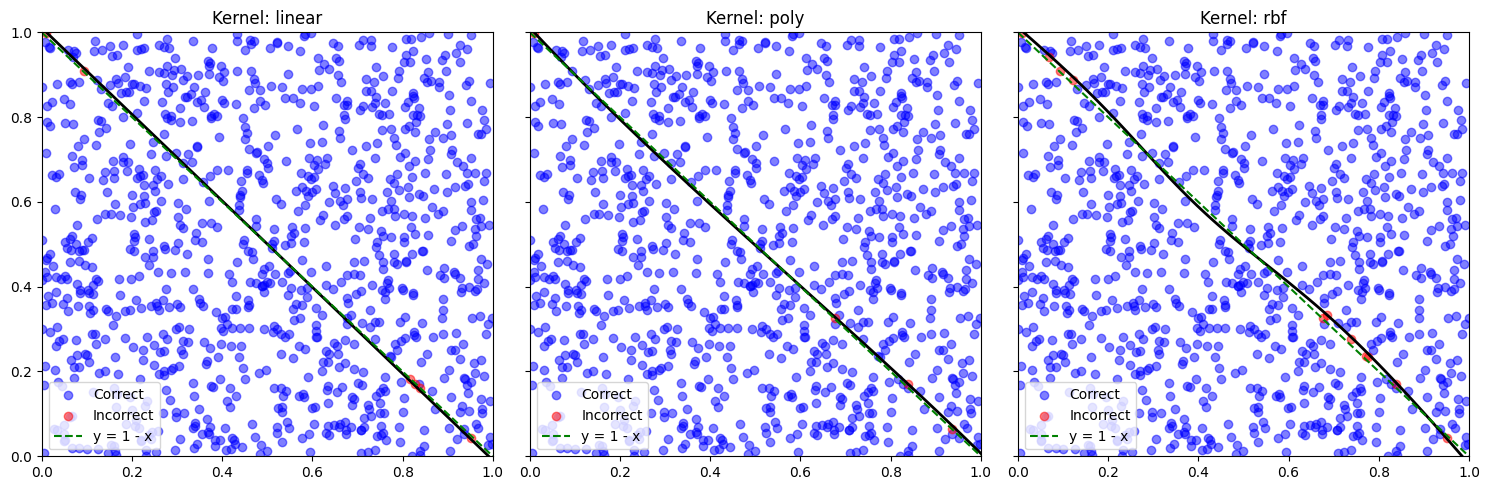

Kernel: linear
  Training Time: 0.0021 seconds
  Testing Time: 0.0017 seconds
Kernel: poly
  Training Time: 0.0020 seconds
  Testing Time: 0.0005 seconds
Kernel: rbf
  Training Time: 0.0016 seconds
  Testing Time: 0.0036 seconds


In [5]:
from sklearn.svm import SVC
import time


# Kernels to try
kernels = ['linear', 'poly', 'rbf']
train_times = []
test_times = []

# Plot setup
fig, axs = plt.subplots(1, len(kernels), figsize=(15, 5), sharey=True)

for i, kernel in enumerate(kernels):
    # Train SVM with the specified kernel
    clf = SVC(kernel=kernel, degree=3 if kernel == 'poly' else 0, gamma='scale')
    start_train = time.time()
    clf.fit(x_train, y_train)
    train_times.append(time.time() - start_train)
    
    # Predict on test data
    start_test = time.time()
    y_pred = clf.predict(x_test)
    test_times.append(time.time() - start_test)
    
    # Separate correct and incorrect predictions
    correct_indices = y_pred == y_test
    incorrect_indices = y_pred != y_test

    # Scatter plot for correct and incorrect predictions
    axs[i].scatter(
        x_test[correct_indices, 0], x_test[correct_indices, 1],
        color='blue', label='Correct', alpha=0.5
    )
    axs[i].scatter(
        x_test[incorrect_indices, 0], x_test[incorrect_indices, 1],
        color='red', label='Incorrect', alpha=0.5
    )
    
    # Plot decision boundary
    x_min, x_max = x_test[:, 0].min() - 0.1, x_test[:, 0].max() + 0.1
    y_min, y_max = x_test[:, 1].min() - 0.1, x_test[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axs[i].contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    
    # Plot separating line (y = 1 - x)
    axs[i].plot(np.linspace(0, 1, 100), 1 - np.linspace(0, 1, 100), color='green', linestyle='--', label='y = 1 - x')
    
    axs[i].set_title(f'Kernel: {kernel}')
    axs[i].legend()
    axs[i].set_xlim([0, 1])
    axs[i].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Print training and testing times
for i, kernel in enumerate(kernels):
    print(f"Kernel: {kernel}")
    print(f"  Training Time: {train_times[i]:.4f} seconds")
    print(f"  Testing Time: {test_times[i]:.4f} seconds")

# Part 2


== Testing for 2 dimensions ==
Kernel: linear, Accuracy: 0.9950
Kernel: rbf, Accuracy: 0.9900
Kernel: poly, Accuracy: 0.9970

== Testing for 5 dimensions ==
Kernel: linear, Accuracy: 0.9960
Kernel: rbf, Accuracy: 0.9860
Kernel: poly, Accuracy: 0.9970

== Testing for 10 dimensions ==
Kernel: linear, Accuracy: 0.9780
Kernel: rbf, Accuracy: 0.9900
Kernel: poly, Accuracy: 1.0000

== Testing for 20 dimensions ==
Kernel: linear, Accuracy: 0.9780
Kernel: rbf, Accuracy: 0.9980
Kernel: poly, Accuracy: 1.0000

== Testing for 50 dimensions ==
Kernel: linear, Accuracy: 0.9750
Kernel: rbf, Accuracy: 0.9990
Kernel: poly, Accuracy: 1.0000


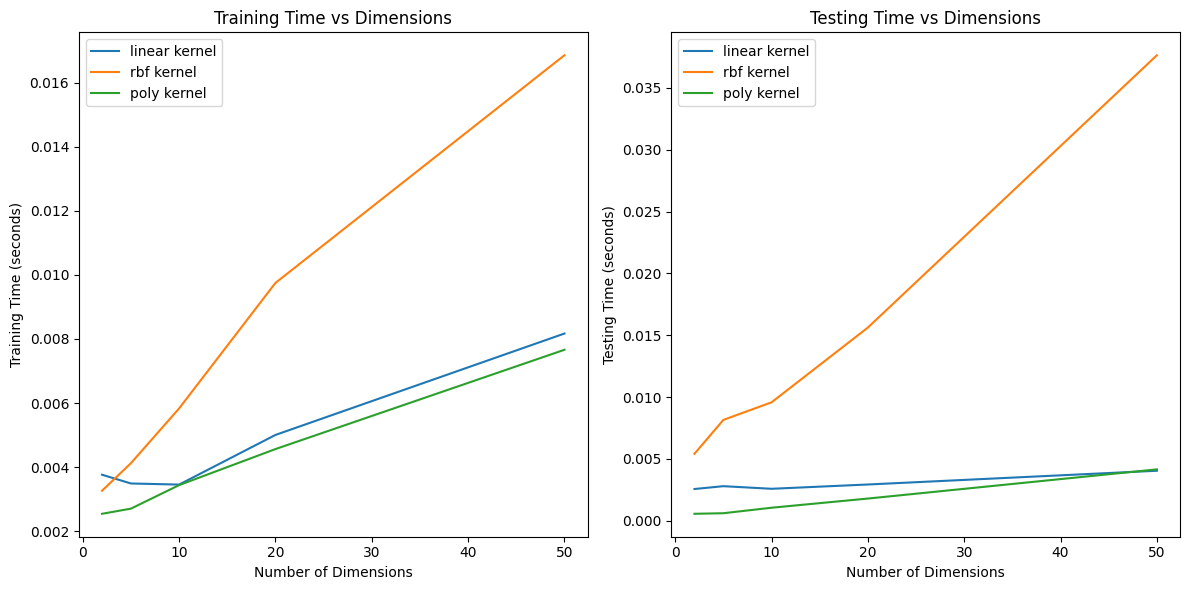

In [ ]:
def generate_data(n_features, n_samples=1000, seed=42):
    np.random.seed(seed)
    data = np.random.uniform(0, 1, (n_samples, n_features))
    threshold = n_features / 2  # Adjusted threshold for higher dimensions
    labels = np.where(data.sum(axis=1) > threshold, 1, 0)

    return data, labels

dimensions = [2, 5, 10, 20, 50]  # Example dimensions to test
kernels = ['linear', 'rbf', 'poly']  # Chosen kernels
train_times = {kernel: [] for kernel in kernels}
test_times = {kernel: [] for kernel in kernels}

for n_dim in dimensions:
    print(f"\n== Testing for {n_dim} dimensions ==")
  
    x_train, y_train = generate_data(n_dim, 1000)
    x_test, y_test = generate_data(n_dim, 1000)

    
    for kernel in kernels:
        clf = SVC(kernel=kernel, gamma='scale')
        
        start_train = time.time()
        clf.fit(x_train, y_train)
        train_times[kernel].append(time.time() - start_train)
        
        start_test = time.time()
        y_pred = clf.predict(x_test)
        test_times[kernel].append(time.time() - start_test)
        
        accuracy = np.mean(y_pred == y_test)
        print(f"Kernel: {kernel}, Accuracy: {accuracy:.4f}")

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

for kernel in kernels:
    axs[0].plot(dimensions, train_times[kernel], label=f'{kernel} kernel')
    axs[1].plot(dimensions, test_times[kernel], label=f'{kernel} kernel')

axs[0].set_title('Training Time vs Dimensions')
axs[0].set_xlabel('Number of Dimensions')
axs[0].set_ylabel('Training Time (seconds)')
axs[0].legend()

axs[1].set_title('Testing Time vs Dimensions')
axs[1].set_xlabel('Number of Dimensions')
axs[1].set_ylabel('Testing Time (seconds)')
axs[1].legend()

plt.tight_layout()
plt.show()

# Part 3

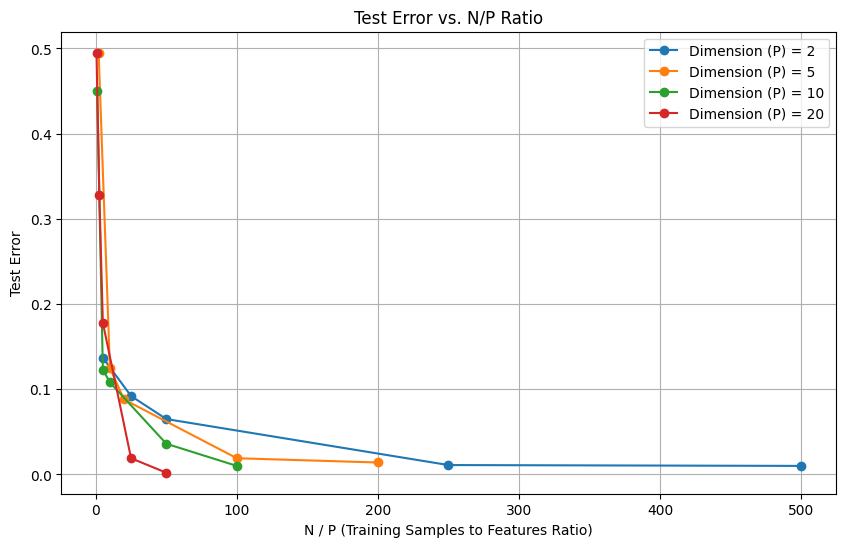

In [18]:
from sklearn.metrics import accuracy_score

# Function to generate balanced dataset
def generate_data(n_features, n_samples, seed=42):
    np.random.seed(seed)
    data = np.random.uniform(0, 1, (n_samples, n_features))
    threshold = n_features / 2  # Balanced threshold
    labels = np.where(data.sum(axis=1) > threshold, 1, 0)
    return data, labels

# Parameters
dimensions = [2, 5, 10, 20]  # Number of features
train_samples = [10, 50, 100, 500, 1000]  # Number of training samples
n_test = 1000  # Fixed number of test samples
repeats = 5  # For averaging results
kernel = 'rbf'  # Kernel type for SVM

# Results storage
errors = {P: [] for P in dimensions}

# Main experiment loop
for P in dimensions:
    for N in train_samples:
        test_errors = []
        for _ in range(repeats):
            # Generate train and test datasets
            x_train, y_train = generate_data(P, N)
            x_test, y_test = generate_data(P, n_test)
            
            # Train SVM
            clf = SVC(kernel=kernel, gamma='scale')
            clf.fit(x_train, y_train)
            
            # Test SVM
            y_pred = clf.predict(x_test)
            test_error = 1 - accuracy_score(y_test, y_pred)
            test_errors.append(test_error)
        
        # Average test error over runs
        errors[P].append(np.mean(test_errors))

# Plot results
plt.figure(figsize=(10, 6))
for P in dimensions:
    ratios = [N / P for N in train_samples]  # Compute N/P ratios
    plt.plot(ratios, errors[P], label=f'Dimension (P) = {P}', marker='o')

plt.title('Test Error vs. N/P Ratio')
plt.xlabel('N / P (Training Samples to Features Ratio)')
plt.ylabel('Test Error')
plt.legend()
plt.grid(True)
plt.show()

# Part 4

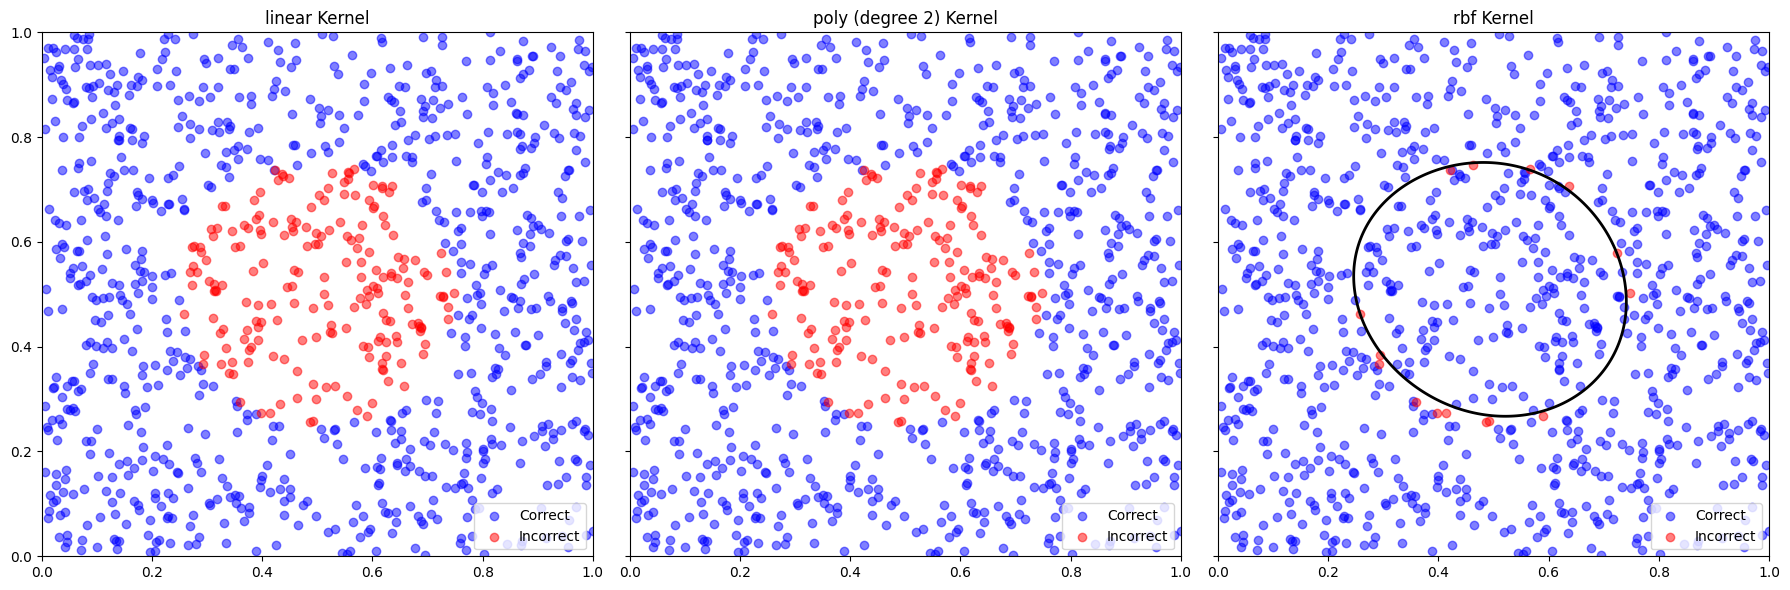

In [ ]:
def generate_circular_data(n_samples, seed=42):
    np.random.seed(seed)
    data = np.random.uniform(0, 1, (n_samples, 2))  # Points in [0, 1] x [0, 1]
    center = np.array([0.5, 0.5])
    radius = 0.25
    distances = np.linalg.norm(data - center, axis=1)
    labels = (distances <= radius).astype(int)  # Inside circle -> 1, Outside -> 0
    return data, labels

n_train = 1000
n_test = 1000
kernels = {
    'linear': {},
    'poly (degree 2)': {'kernel': 'poly', 'degree': 2},
    'rbf': {'kernel': 'rbf'}
}

x_train, y_train = generate_circular_data(n_train)
x_test, y_test = generate_circular_data(n_test)

fig, axs = plt.subplots(1, len(kernels), figsize=(18, 6), sharey=True)

for i, (kernel_name, params) in enumerate(kernels.items()):
    clf = SVC(kernel=params.get('kernel', 'linear'), degree=params.get('degree', 3), gamma='scale')
    clf.fit(x_train, y_train)
    
    y_pred = clf.predict(x_test)
    
    correct_indices = y_pred == y_test
    incorrect_indices = ~correct_indices
    
    axs[i].scatter(
        x_test[correct_indices, 0], x_test[correct_indices, 1],
        color='blue', label='Correct', alpha=0.5
    )
    axs[i].scatter(
        x_test[incorrect_indices, 0], x_test[incorrect_indices, 1],
        color='red', label='Incorrect', alpha=0.5
    )
    
    x_min, x_max = 0, 1
    y_min, y_max = 0, 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axs[i].contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    
    axs[i].set_title(f'{kernel_name} Kernel')
    axs[i].set_xlim([0, 1])
    axs[i].set_ylim([0, 1])
    axs[i].legend()

plt.tight_layout()
plt.show()